# Analyse des déterminants de l'espérance de vie moyenne des pays

Lia Biscafe, Raphaël Contri

## Introduction

L'espérance de vie est un indicateur central du développement humain, car elle reflète à la fois les conditions sanitaires, sociales et économiques d'une population. Comprendre les facteurs qui la déterminent est donc essentiel pour orienter les politiques publiques en matière de santé, d’éducation ou encore de lutte contre la pauvreté. Si l'on peut observer des tendances globales à la hausse de l’espérance de vie au cours des dernières décennies, il reste important d’en analyser les causes sur des périodes suffisamment longues.

Dans cette étude, nous cherchons à analyser les données moyennes sur une période 15 ans, de 2000 à 2015. Notre analyse ne prend pas en compte l'évolution dans le temps des variables explicatives mais permet de tirer des informations plus précises qu'une analyse sur une seule année. 

Notre jeu de données est composé de deux types d'indicateurs : les indicateurs économiques et les indicateurs de santé. Les indicateurs économiques provienennt de données des Nations Unies et ceux de santé proviennent plus spécifiquement de l'Organisation Mondiale de la Santé (OMS). (lien du dataset : https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who). 

En nous appuyant sur ce jeu de données, nous cherchons à identifier les principaux déterminants de l’espérance de vie dans le monde. Notre objectif est de construire un modèle de régression linéaire multiple permettant de mieux comprendre quelles variables influencent significativement cet indicateur.

Pouvoir prédire l’espérance de vie en fonction de facteurs mesurables permettrait non seulement d’éclairer les décideurs sur les leviers d’action les plus efficaces, mais aussi de mieux anticiper les besoins futurs en matière de santé publique et de protection sociale.

Ainsi, nous posons la question suivante : quels sont les facteurs économiques et sanitaires ayant une influence significative sur l’espérance de vie moyenne d’un pays ?



#### Précisions sur le jeu de données :
-  Life expectancy in age
-  Adult Mortality Rates of both sexes (probability of dying between 15 and 60 years per 1000 population)
-  Number of Infant Deaths per 1000 population
-  Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)
-  Expenditure on health as a percentage of Gross Domestic Product per capita(%)
-  Hepatitis B (HepB) immunization coverage among 1-year-olds (%)
-  Measles - number of reported cases per 1000 population
-  BMI : Average Body Mass Index of entire population
-  under five death : Number of under-five deaths per 1000 population
-  Polio (Pol3) immunization coverage among 1-year-olds (%)
-  total expenditure : General government expenditure on health as a percentage of total government expenditure (%)
-  diphteria : Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)
-  HIV / AIDS : Deaths per 1 000 live births HIV/AIDS (0-4 years)
-  GDP : Gross Domestic Product *per capita* (in USD)
-  thinness 1-19 years old : Prevalence of thinness among children and adolescents for Age 10 to 19 (% )
-  thinness 5-9 years old : Prevalence of thinness among children for Age 5 to 9(%)
-  income composition of ressources : Human Development Index in terms of income composition of resources (index ranging from 0 to 1)
-  number of years of schooling : Number of years of Schooling(years)

#### Sommaire

**I. Préliminaires**
- I.A. Installation des librairies
- I.B. Nettoyage et prise en main des données
- I.C. Analyse descriptive
    
**II. Estimation du modèle linéaire**
- II.A. Normaliser les données
- II.B.Regression linéaire multiple sur l'ensemble des variables explicatives ; analyse de la significativité des variables
    
**III. Analyse des résidus**
- III.A. Vérification de l'hypothèse de gaussianité des résidus
- III.B. Analyse des valeurs aberrantes
- III.C. Analyse des points leviers
- III.D. Analyse des valeurs isolées avec la distance de Cook
- III.E. Conclusion
    
**IV. Sélection des variables**
- IV.A Format du dataset
- IV.B. Calcul de R2, R2 ajusté, AIC, BIC
- IV.C. Sélectionner les variables en fonction de AIC et BIC
- IV.D. Sélections des variables suivant le VIF
- IV.E. Tests des différents modèles
- IV.F. Conclusion, choix du modèle

## I. Préliminaires

#### I.A. Installation des librairies

In [8]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_error

#### I.B. Nettoyage et prise en main des données

In [10]:
df = pd.read_csv("Life Expectancy Data.csv")
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


On remarque qu'il y a beaucoup trop de lignes et surtout plusieurs lignes par pays. De plus, il y a des colonnes avec des variables discrètes, qui ne seront donc pas utiles pour la régression linéaire. De la même façon, les colonnes non numériques ne sont pas utiles pour la régression, elles sont donc supprimées.

Aussi, on décide de grouper les lignes qui appartiennet au même pays. Les colonnes obtenues sont formées par les moyennes sur les 15 années dont on dispose. Cela revient à supprimer la dimension temporelle du dataset.

Le dataset contenait des données manquantes dans chacune des colonnes. Si les données manquantes concernaient la variable d'interêt (ici l'espérance de vie), nous avons supprimé la ligne. Au total, cela a représenté 10 pays sur 193. Pour les autres variables, nous avons choisi de remplacer les données manquantes par la moyenne.

In [12]:
#On supprime les colonnes qui ne sont pas des données chiffrées
df = df.drop('Status', axis=1)
df = df.drop('Year', axis=1)

In [13]:
#On groupe toutes les lignes d'un même pays et on fait les moyennes pour remplir les nouvelles valeurs
df = df.groupby("Country", as_index=False).mean()

In [14]:
#on regarde s'il y a des NA 
df.isnull().sum()

Country                             0
Life expectancy                    10
Adult Mortality                    10
infant deaths                       0
Alcohol                             2
percentage expenditure              0
Hepatitis B                         9
Measles                             0
 BMI                                4
under-five deaths                   0
Polio                               0
Total expenditure                   2
Diphtheria                          0
 HIV/AIDS                           0
GDP                                30
Population                         48
 thinness  1-19 years               4
 thinness 5-9 years                 4
Income composition of resources    17
Schooling                          13
dtype: int64

In [15]:
df = df.dropna(subset=['Life expectancy ']).reset_index(drop=True)

On obtient alors le dataset final : 

In [17]:
#On remplace les NA pas les valeurs moyennes
df = df.fillna(df.mean(numeric_only=True))
df

,Country,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,58.19375,269.0625,78.2500,0.014375,34.960110,64.562500,2362.2500,15.51875,107.5625,48.3750,8.252500,52.3125,0.10000,340.015425,9.972260e+06,16.58125,15.58125,0.415375,8.21250
1,Albania,75.15625,45.0625,0.6875,4.848750,193.259091,98.000000,53.3750,49.06875,0.9375,98.1250,5.945625,98.0625,0.10000,2119.726679,6.969116e+05,1.61875,1.70000,0.709875,12.13750
2,Algeria,73.61875,108.1875,20.3125,0.406667,236.185241,78.000000,1943.8750,48.74375,23.5000,91.7500,4.604000,91.8750,0.10000,2847.853392,2.164983e+07,6.09375,5.97500,0.694875,12.71250
3,Angola,49.01875,328.5625,83.7500,5.740667,102.100268,70.222222,3561.3125,18.01875,132.6250,46.1250,3.919333,47.6875,2.36875,1975.143045,1.014710e+07,6.19375,6.66875,0.458375,8.04375
4,Antigua and Barbuda,75.05625,127.5000,0.0000,7.949333,1001.585226,98.266667,0.0000,38.42500,0.0000,96.9375,4.791333,98.3125,0.12500,9759.305728,1.274585e+07,3.42500,3.37500,0.488625,8.84375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,Venezuela (Bolivarian Republic of),73.38750,163.0000,9.3750,7.420000,0.000000,66.250000,165.0000,54.48750,10.7500,74.6875,4.998667,68.5000,0.10000,7389.061605,1.274585e+07,1.65000,1.56250,0.726812,12.78750
179,Viet Nam,74.77500,126.5625,29.1875,3.087333,0.000000,87.538462,4232.9375,11.18750,36.5000,94.9375,5.977333,91.7500,0.14375,7389.061605,1.274585e+07,14.92500,15.62500,0.627062,11.51250
180,Yemen,63.86250,211.8125,39.3750,0.047333,0.000000,55.687500,2761.1875,33.48750,51.6250,67.1250,5.005333,72.6250,0.10000,7389.061605,1.274585e+07,13.83125,13.75000,0.475500,8.50625
181,Zambia,53.90625,354.3125,33.4375,2.239333,89.650407,69.818182,6563.8125,17.45000,52.3750,64.3750,5.824000,74.2500,11.93125,811.811841,6.260246e+06,6.88125,6.76250,0.498437,11.21250


On vérifie ensuite qu'il n'y a plus aucune valeur manquante avec la commande `df.isnull().sum()`

In [19]:
#on vérifie qu'il n'y a plus de NA.
df.isnull().sum()

Country                            0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

#### I.C. Analyse descriptive

Pour appréhender le dataset, on commence par effectuer une analyse descriptive de celui-ci. On étudie des premières statistiques simples sur le jeu de données. On obtient alors la table, le boxplot et le violinplot de la life expectancy suivante : 

In [22]:
df.describe()

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,1.830000e+02,183.000000,183.000000,183.000000,183.000000
mean,69.224932,164.796448,30.407445,4.612109,740.321185,78.657263,2427.855874,38.235394,42.179303,82.393862,5.913418,82.180816,1.747712,7389.061605,1.274585e+07,4.850622,4.881423,0.627419,11.999639
std,9.186432,96.185159,115.995720,3.837830,1480.930026,16.995104,8080.986907,15.823028,157.427874,15.998312,1.912332,16.520129,4.447630,10038.925845,3.391818e+07,4.073337,4.159421,0.178586,3.041630
min,46.112500,18.750000,0.000000,0.010000,0.000000,9.000000,0.000000,11.187500,0.000000,29.812500,1.646667,26.812500,0.100000,137.815321,3.334250e+03,0.100000,0.100000,0.131687,1.531250
25%,62.475000,80.406250,0.000000,1.248667,32.401540,68.842424,8.187500,20.887500,0.187500,71.593750,4.691333,72.375000,0.100000,1063.772982,1.525259e+06,1.756250,1.731250,0.488438,10.156250
50%,72.487500,146.562500,2.937500,3.702667,183.662908,81.062500,175.000000,42.681250,3.687500,87.812500,5.913418,88.000000,0.100000,3933.012175,6.143695e+06,3.662500,3.793750,0.647625,12.225000
75%,75.106250,219.593750,22.125000,7.527333,523.622686,93.366667,1526.156250,51.987500,30.218750,95.875000,7.051000,95.687500,0.996875,7389.061605,1.274585e+07,7.131250,7.015625,0.754000,13.971875
max,82.537500,550.062500,1366.687500,13.497333,9801.810377,98.875000,65857.937500,69.431250,1812.500000,98.937500,15.863333,99.000000,32.943750,57362.874601,4.214677e+08,27.100000,27.943750,0.931438,20.037500


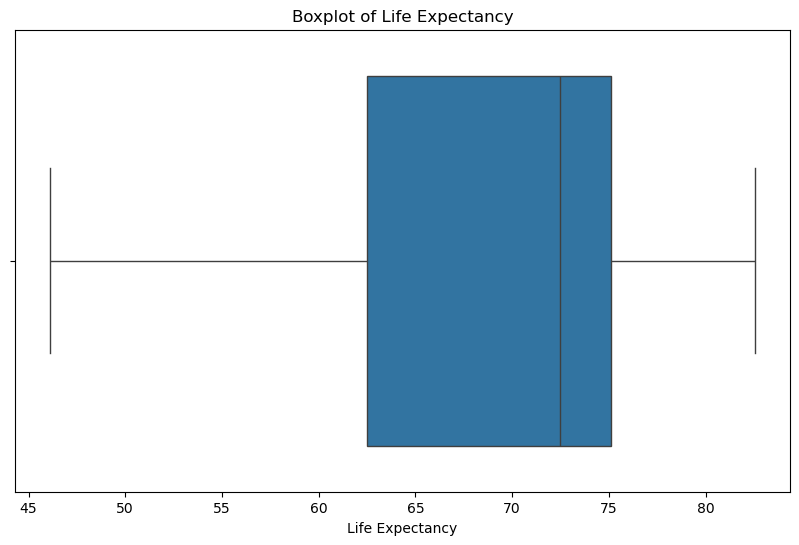

In [23]:
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.boxplot(x=df['Life expectancy '])
plt.title('Boxplot of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.show()

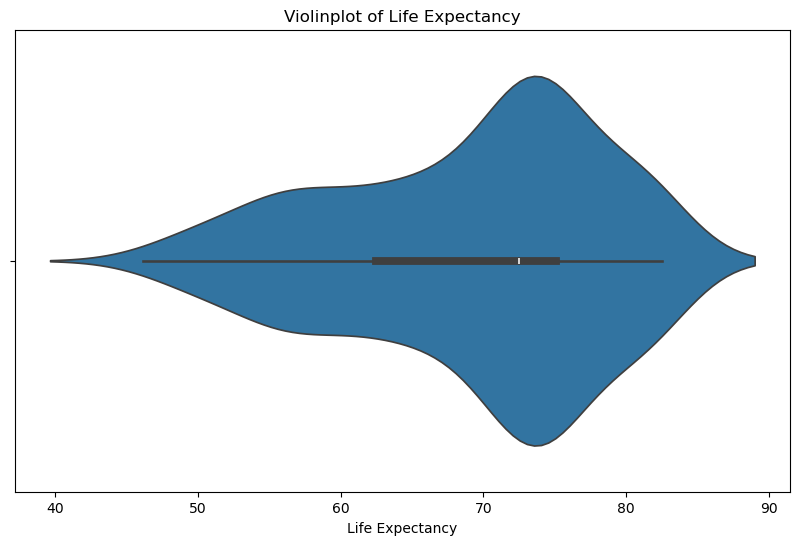

In [24]:
plt.figure(figsize=(10, 6))  # Taille de la figure
sns.violinplot(x=df['Life expectancy '])  # Utilisation du violinplot
plt.title('Violinplot of Life Expectancy')  # Titre du graphique
plt.xlabel('Life Expectancy')  # Label de l'axe X
plt.show()

On analyse tout d'abord les informations relatives à la variable d'intérêt life expectancy : 

La moyenne de l'espérance de vie de tous les pays entre 2000 et 2015 est de 69 ans, et son écart type est de 9 ans. De plus, 25% des pays ont une moyenne d'age inférieure à 62 ans, 50% ont une moyennne d'âge inférieure à 72 ans et 75% de 75 ans : entre le Q3 et le Q2 il y a très peu de différences (on le voit mieux dans le boxplot suivant). On peut comprendre la disparité dans l'espérance de vie dans la mesure où les pays présents dans le dataset présentent des caractéristiques très variables. En effet, en observant les autres colonnes de la table ci-dessus, on remarque que le pib par tête peut être très variable (écart type de 10038 $ ), et si le pib par tête est explicatif de l'espérance de vie, alors on aurait une explication de pourquoi l'écart type est de 9 ans. 

On observe aussi des pays où l'espérance de vie est très faible : minimum à 46 ans, ou très haute : maximum à 82 ans. Néanmoins d'après le violinplot, très peu de pays sont dans ces tranches d'age d'espérance de vie. 
Le violinplot nous montre bien une dichotomie entre deux "catégories" de pays : un certain nombre de pays ont une espérance de vie qui varie de ~52 à 65 ans mais la grande majorité des pays ont une espérance de vie qui varie de 70 à 75 ans. En revanche, très peu de pays ont une espérance de vie en dessous de 50 ans et au dessus de ~80 ans. 

On analyse ensuite les corrélations entre les différentes variables et avec la variable d'intérêt.

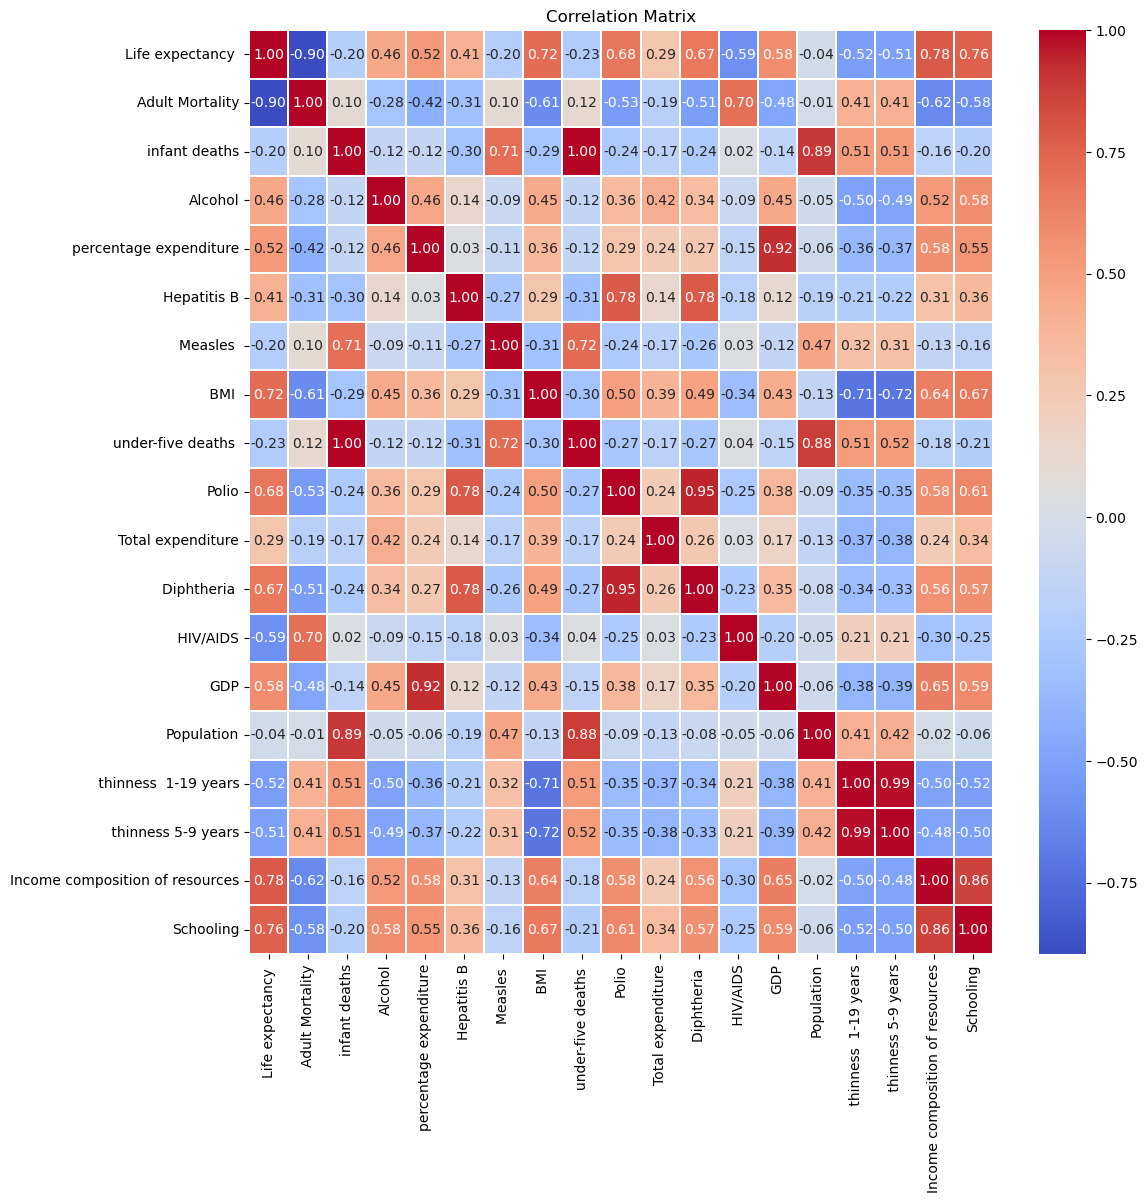

In [27]:
# Exclude non-numeric columns before calculating the correlation matrix
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize = (12, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidth = 0.05)
# Show the plot
plt.title("Correlation Matrix")
plt.show()

On peut analyser cette matrice de corrélation de deux manières possibles : 
- (1) En regardant les corrélations entre les variables explicatives entre elles. Si il y a beaucoup de colinéarité entre deux variables explicatives, alors il y a de la multicolinéarité, ce qui est mauvais pour modèle (la matrice ne serait donc plus de rang plein et une des hypothèses de départ ne serait plus respectée). On mesure la multicolinéarité entre les variables explicatives avec le VIF facteur d'inflation de la variance. L'analyse du VIF est aussi en dessous, mais on peut prédire que les variables qui auront un VIF élevé d'après cette matrice de corrélation seront entre autres infant death et under five death (ce qui n'est pas étonnant car les moins de 5 ans sont des enfants).
- (2) En regardant les corrélations entre la variable d'intérêt et les variables explicatives : 


In [29]:
correlation_with_life_expectancy = df.drop(columns=['Country']).corr()['Life expectancy '].drop('Life expectancy ').to_frame().style.background_gradient(cmap='coolwarm')  # or cmap='RdBu'
correlation_with_life_expectancy

,Life expectancy
Adult Mortality,-0.896441
infant deaths,-0.199914
Alcohol,0.458145
percentage expenditure,0.524320
Hepatitis B,0.411867
Measles,-0.201076
BMI,0.716881
under-five deaths,-0.225785
Polio,0.679231
Total expenditure,0.288295


De ce tableau on remarque que 
- les variables infant death, measles, under five death et population corrèlent peu avec la variable d'intérêt. On peut émettre l'hypothèse qu'elles seront peu explicatives (hypothèse que l'on vérifiera dans la partie II. Estimation du modèle linéaire).
- les variables schooling, income composition of ressources, diphteria, BMI, Polio semblent bien plus corréler et on peut donc émettre l'hypothèse qu'elles expliquent mieux le modèle que les autres

Ensuite, on calcule le VIF pour vérifier la multicolinéarité entre les colonnes de la matrice : 

In [32]:
X = df.drop(columns=['Life expectancy '], errors='ignore')
X = X.select_dtypes(include=[np.number])
# Suppression des colonnes avec des valeurs manquantes si nécessaire
# X = X.dropna(axis=1)

# Ajout d'une constante (intercept) pour le modèle
X_with_const = add_constant(X)

# Calcul du VIF pour chaque variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

# Tri des résultats par VIF décroissant
vif_data = vif_data.sort_values("VIF", ascending=False)

# Affichage des résultats
print(vif_data)

# Interprétation des résultats
print("\nInterprétation:")
print("- VIF = 1: Pas de corrélation")
print("- 1 < VIF < 5: Corrélation modérée")
print("- 5 < VIF < 10: Corrélation élevée")
print("- VIF > 10: Corrélation très élevée, problème potentiel de multicolinéarité")

                           Variable         VIF
2                     infant deaths  257.763313
8                under-five deaths   228.709346
0                             const  128.619903
16               thinness 5-9 years   38.282348
15             thinness  1-19 years   37.880101
9                             Polio   11.116114
11                      Diphtheria    10.703753
13                              GDP    8.749185
14                       Population    8.475173
4            percentage expenditure    8.196179
18                        Schooling    5.210962
17  Income composition of resources    5.114073
1                   Adult Mortality    3.973628
7                              BMI     3.836729
5                       Hepatitis B    3.516326
6                          Measles     3.188724
12                         HIV/AIDS    2.270577
3                           Alcohol    2.019712
10                Total expenditure    1.503506

Interprétation:
- VIF = 1: Pas de corré

On en déduit ce qu'on avait plus  ou moins prévu ci dessus : il y a quatre variables (infant death, under-five death, thinness 5-9 years et thinness 1-19 years) qui corrèlent énormément et qui sont donc problématiques. On verra plus tard avec la sélection de variables s'il faut les enlever (partie "sélection de variables"). Cette multicolinéarité peut être comprise par le fait que la thinness 5-9 ans est comprise dans la thinness 1-19 ans, et, comme expliqué plus haut, les enfants de moins de 5 ans sont des enfants. Cependant, le cond. number qui mesure la multicolinéarité dans le dataset est relativement faible (cf II.). 

## II. Estimation du modèle linéaire

#### II.A. Normaliser les données

La première étape avant de réaliser une régression linéaire multiple est de normaliser les données. Cela permet de rendre les données comparables lors de l'interprétation. En effet, certains indicateurs sont entre 0 et 10 quand d'autres sont en milliers, ce qui pourrait rendre l'analyse difficile.

In [37]:
country_col = df["Country"] if "Country" in df.columns else None

# 1. Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include='number').columns

# 2. Normalisation uniquement des colonnes numériques
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)

# 3. Reconstituer le DataFrame complet avec la colonne 'Country' si elle était là
if country_col is not None:
    df = pd.concat([country_col.reset_index(drop=True), df_scaled], axis=1)
else:
    df = df_scaled

In [38]:
df

,Country,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,-1.204107,1.086988,0.413583,-1.201290,-0.477603,-0.831618,-0.008141,-1.439609,0.416461,-2.132237,1.226513,-1.812956,-0.371486,-7.040978e-01,-8.199725e-02,2.887758,2.579489,-1.190609,-1.248518
1,Albania,0.647432,-1.248243,-0.256919,0.061829,-0.370418,1.141258,-0.294642,0.686536,-0.262691,0.985998,0.016888,0.963991,-0.371486,-5.263303e-01,-3.562099e-01,-0.795598,-0.766970,0.462986,0.045449
2,Algeria,0.479607,-0.590156,-0.087267,-1.098793,-0.341352,-0.038780,-0.060056,0.665940,-0.118979,0.586425,-0.686602,0.588420,-0.371486,-4.536010e-01,2.632336e-01,0.306024,0.263637,0.378762,0.235011
3,Angola,-2.205603,1.707284,0.461128,0.294868,-0.432142,-0.497683,0.140647,-1.281178,0.576098,-2.273263,-1.045611,-2.093685,0.140017,-5.407722e-01,-7.682837e-02,0.330641,0.430885,-0.949167,-1.304150
4,Antigua and Barbuda,0.636517,-0.388821,-0.262862,0.871946,0.176903,1.156992,-0.301265,0.012016,-0.268663,0.911567,-0.588372,0.979166,-0.365850,2.367531e-01,-1.101330e-16,-0.350949,-0.363165,-0.779316,-1.040412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,Venezuela (Bolivarian Republic of),0.454364,-0.018728,-0.181818,0.733642,-0.501274,-0.732052,-0.280790,1.029935,-0.200190,-0.483020,-0.479656,-0.830402,-0.371486,1.816907e-16,-1.101330e-16,-0.787905,-0.800118,0.558088,0.259737
179,Viet Nam,0.605817,-0.398594,-0.010546,-0.398391,-0.501274,0.524008,0.223987,-1.714090,-0.036175,0.786211,0.033515,0.580833,-0.361622,1.816907e-16,-1.101330e-16,2.480035,2.590036,-0.002000,-0.160597
180,Yemen,-0.585335,0.490149,0.077521,-1.192679,-0.501274,-1.355260,0.041362,-0.300885,0.060165,-0.957023,-0.476160,-0.580022,-0.371486,1.816907e-16,-1.101330e-16,2.210784,2.138016,-0.853012,-1.151676
181,Zambia,-1.672108,1.975731,0.026194,-0.619956,-0.440572,-0.521523,0.513217,-1.317221,0.064942,-1.129388,-0.046887,-0.481387,2.295937,-6.569721e-01,-1.917377e-01,0.499885,0.453486,-0.724219,-0.259498


#### II.B. Regression linéaire multiple sur l'ensemble des variables explicatives ; analyse de la significativité des variables

On peut alors effectuer une régression linéaire multiple. Le calcul des coefficients et statistiques sont réalisés avec la fonction sm.OLS.

In [41]:
#Régression linéaire multiple avec toutes les colonnes

X = df.drop(columns=['Life expectancy ',"Country"]) 
#on supprime la variable qu'on veut expliquer of course mais aussi Country car non numérique
y = df['Life expectancy ']

print(X.dtypes[X.dtypes != 'float64']) 

X = sm.add_constant(X)

mod2 = sm.OLS(y, X).fit()

print(mod2.summary())

Series([], dtype: object)
                            OLS Regression Results                            
Dep. Variable:       Life expectancy    R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     127.7
Date:                Tue, 20 May 2025   Prob (F-statistic):           1.46e-86
Time:                        22:14:14   Log-Likelihood:                -11.749
No. Observations:                 183   AIC:                             61.50
Df Residuals:                     164   BIC:                             122.5
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

**Interprétation de cette régression linéaire et significativité des variables**
- Le critère R2 est de 0.933. Cela signifie donc que 93,3% de la variance de l'espérance de vie est expliquée par notre modèle, ce qui est très satisfaisant.
- Le critère R2 ajusté qui permet de prendre en compte le nombre élevé de variables explicatives reste élevé, ce qui est aussi satisfaisant. (il ajuste  la valeur du r-carré en pénalisant l'inclusion de variables non pertinentes, c'est-à-dire fortement colinéaires, le R2 ajusté peut diminuer si un effet spécifique n'améliore pas le modèle.
- **significativité des variables** : La F-statistic est de 127,7 avec une p-valeur très faible (1.46e-86). La p-valeur donne la probabilité que la F-statistic serait aussi elevée si le modèle n'expliquait rien du tout. Ici, c'est tout à fait improbable, donc notre modèle est explicatif. On rejette donc l'hypothèse H0 (tous les coefficients de la régression linéaire sont égaux à 0) au profit de H1 (il existe au moins un coefficient non nul)
- Les autres données relatives à l'analyse des résidus, AIC / BIC etc. seront analysées par la suite.
- => nous avons donc un plutot bon modèle de régression linéaire, avec une variance bien expliquée par le modèle et des coefficients explicatifs.

## III. Analyse des résidus

Nous analysons ensuite les résidus pour vérifier la validité des hypothèses du modèle et évaluer la qualité de l’ajustement. 

#### III.A. Vérification de l'hypothèse de gaussianité des résidus

On vérifie tout d'abord l'hypothèse de gaussianité des résidus en traçant un QQ-plot.
D'après wikipedia, "Le diagramme Q-Q de comparaison d'une distribution observée avec une loi gaussienne réduite permet une validation subjective : si les points sont alignés sur la première bissectrice c'est que la distribution suit probablement une loi de distribution gaussienne normalisée. Si les points sont alignés sur une autre droite d'équation x i = a x i ∗ + b {\displaystyle x_{i}=ax_{i}^{*}+b}, c'est que la distribution observée suit une loi normale d'espérance b et d'écart type a." (https://fr.wikipedia.org/wiki/Diagramme_quantile-quantile)

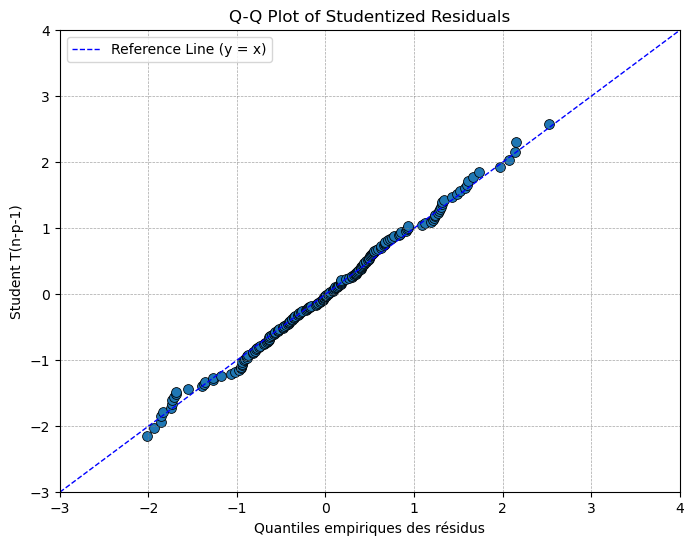

In [47]:
## vérifier la normaté des résidus (correction TP 1
from scipy.stats import t
residu_student = mod2.get_influence().resid_studentized_external

# 2. Create DataFrame
df_residus = pd.DataFrame({"residu": residu_student})
# 1. Compute Theoretical Quantiles (Student T-distribution)
n = len(df_residus)  # Number of observations
p = 2  # Number of predictors including intercept
quant_t = t.ppf((np.arange(1, n + 1) / n), df=n - p - 1)  # Equivalent to qt((1:n)/n, n-3)

# 2. Create DataFrame for Q-Q Plot
df_qq = pd.DataFrame({"Obs": np.sort(df_residus["residu"]), "Theo": quant_t})

# 3. Create the Q-Q Plot
plt.figure(figsize=(8, 6))

# Scatter plot of observed vs theoretical quantiles
sns.scatterplot(x=df_qq["Obs"], y=df_qq["Theo"], marker="o", s=50, edgecolor="black")

# Add the 45-degree reference line (slope = 1, intercept = 0)
plt.plot([-3, 4], [-3, 4], linestyle="dashed", color="blue", linewidth=1, label="Reference Line (y = x)")

# Labels and title
plt.xlabel("Quantiles empiriques des résidus")
plt.ylabel("Student T(n-p-1)")
plt.xlim(-3, 4)
plt.ylim(-3, 4)

# Show plot
plt.legend()
plt.title("Q-Q Plot of Studentized Residuals")
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
plt.show()


Les points sont plutot bien alignés sur une droite linéaire  passant par l'origine , ce qui confirme l'hypothèse selon laquelle les résidus théoriques $\varepsilon_i$ suivent la loi normale $\mathcal N(0,\sigma^2)$ et montre que les résidus suivent une noi normale $\mathcal N(0,1)$ car f(x) = x

Par ailleurs, on peut vérifier d'autres hypothèses sur les résidus à partir de la table de régression linéaire du II. : Par exemple, le test de Durbin-Watson est égal à 2.040, et d'après wikipedia, "L'hypothèse nulle (non autocorrélation) est retenue si la statistique a une valeur proche de 2 (pas d'auto-corrélation linéaire)" (https://fr.wikipedia.org/wiki/Test_de_Durbin-Watson). Or, "La présence d'une autocorrélation des résidus signifie que le modèle linéaire n'est pas adapté à la forme du nuage de point et que la relation liant les deux variables X et Y est plus compliquée (non-linéaire)." (http://grasland.script.univ-paris-diderot.fr/STAT98/stat98_7/stat98_7.htm). L'hypothèyse d'homoscédastésité des résidus est donc valide

#### III.B. analyse des valeurs aberrantes

On analyse ensuite les valeurs aberrantes, qui sont des valeurs qui sont mal expliquées par le modèle, avec un résidu studentisé élevé. 

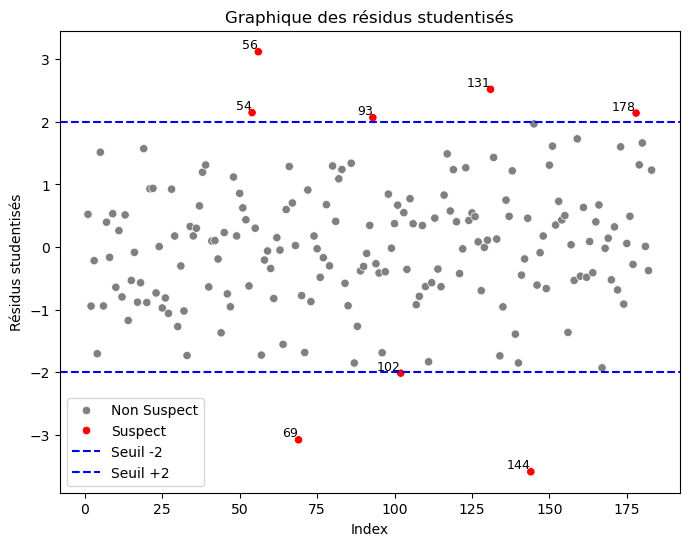

In [52]:
## chercher les valeurs aberrantes 
# 1. Compute Studentized Residuals
residu_student = mod2.get_influence().resid_studentized_external

# 2. Create DataFrame
df_residus = pd.DataFrame({"residu": residu_student})

# Number of observations
n = len(df["Country"])

# 3. Identify Observations with |Residual| > 2 (Potential Outliers)
IDval_ab = np.where(np.abs(df_residus["residu"]) > 2)[0] + 1  # Convert to 1-based index

# 4. Add Identifier Column for Outliers
df_residus["ID"] = ""
df_residus.loc[IDval_ab - 1, "ID"] = IDval_ab  # Adjust back to 0-based index

# 5. Assign Groups Based on Residuals
df_residus["group"] = "Non Suspect"
df_residus.loc[IDval_ab - 1, "group"] = "Suspect"

# 6. Plot Studentized Residuals
plt.figure(figsize=(8, 6))

# Scatter plot with color for groups
sns.scatterplot(x=np.arange(1, n + 1), y=df_residus["residu"], hue=df_residus["group"], palette={"Non Suspect": "gray", "Suspect": "red"})

# Add threshold lines at ±2
plt.axhline(y=-2, color="blue", linestyle="dashed", label="Seuil -2")
plt.axhline(y=2, color="blue", linestyle="dashed", label="Seuil +2")
valeurs_aberrantes = list()
# 7. Add Labels for Outliers
for i, txt in enumerate(df_residus["ID"]):
    if txt:  # Only label outliers
        plt.text(i + 1, df_residus["residu"].iloc[i], s=txt, fontsize=9, verticalalignment='bottom', horizontalalignment='right')
        valeurs_aberrantes.append(i+1)

# Labels and title
plt.xlabel("Index")
plt.ylabel("Résidus studentisés")
plt.title("Graphique des résidus studentisés")

# Add legend
plt.legend()

# Show plot
plt.show()

Il y a 8 observations aberrantes, ce qui est plutot cohérent puisqu'il en y a en moyenne 5% (ici, de 180 = 9).
Les observations aberrantes sont : 
- Estonia  
- Fiji  
- Guyana  
- Liberia  
- Malta  
- Republic of Moldova  
- Singapore  
- Venezuela (Bolivarian Republic of)


Les espérances de vie là ne sont donc pas bien expliquées par le modèle, mais cela ne signifie pas que ces pays ont une forte influence sur le modèle. Pour mesurer l'influence des observations sur le modèle, on étudie les points leviers grâce aux coefficients diagonaux de la matrice chapeau.

In [55]:
pays_aberrants = [df.iloc[e]["Country"] for e in valeurs_aberrantes]
pays_aberrants

['Estonia',
 'Fiji',
 'Guyana',
 'Liberia',
 'Malta',
 'Republic of Moldova',
 'Singapore',
 'Venezuela (Bolivarian Republic of)']

#### III.C. Analyse des points leviers

On regarde ensuite les points leviers en observant les coefficients diagonaux de la matrice chapeau. Les coefficients supérieurs à 2p/n ou 3p/n sont des points leviers. (avec p le nombre de variables explicatives et n le nombre de lignes)

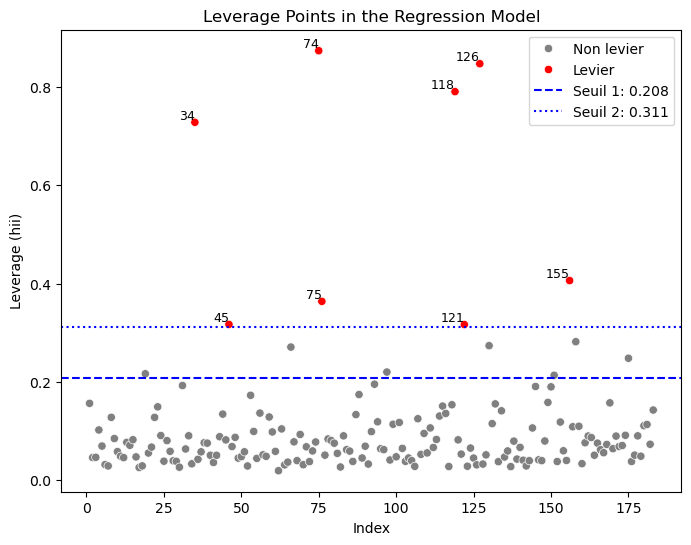

In [58]:
## recherche des points leviers 

# Step 1: Get residuals (raw residuals e_i)
residuals = mod2.resid

# Step 2: Calculate sigma_hat (standard error of regression)
sigma_hat = np.sqrt(np.sum(residuals**2) / (len(residuals) - mod2.df_model - 1))

# Step 3: Get leverage (h_i)
influence = mod2.get_influence()
hii = influence.hat_matrix_diag  # Leverage values

# Step 4: Compute standardized residuals
standardized_residuals1 = residuals / (sigma_hat * np.sqrt(1 - hii))


##########################################################################

n = len(df)
p = mod2.df_model + 1  # Number of parameters (including intercept)
seuil1 = 2 * p / n
seuil2 = 3 * p / n

# Create DataFrame for leverage values
df_H = pd.DataFrame({"H": hii})

# Identify points with leverage greater than seuil2
ID_levier = df_H["H"] > seuil2

# Assign labels and group for plotting
df_H["ID"] = ""
df_H.loc[ID_levier, "ID"] = np.where(ID_levier)[0]  # Adjust to 0-based indexing
df_H["group"] = "Non levier"
df_H.loc[ID_levier, "group"] = "Levier"

# Create the plot
plt.figure(figsize=(8, 6))

# Scatter plot with color based on group (Levier vs Non levier)
sns.scatterplot(x=np.arange(1, n+1), y=df_H["H"], hue=df_H["group"], palette={"Non levier": "gray", "Levier": "red"})

# Add threshold lines for seuil1 and seuil2
plt.axhline(y=seuil1, color="blue", linestyle="dashed", label=f"Seuil 1: {seuil1:.3f}")
plt.axhline(y=seuil2, color="blue", linestyle="dotted", label=f"Seuil 2: {seuil2:.3f}")
points_leviers = list()
# Add labels for high leverage points
for i, txt in enumerate(df_H["ID"]):
    if txt:  # Only label points that are high leverage
        plt.text(i + 1, df_H["H"].iloc[i], s=txt, fontsize=9, verticalalignment='bottom', horizontalalignment='right')
        points_leviers.append(i+1)

# Add labels and title
plt.xlabel("Index")
plt.ylabel("Leverage (hii)")
plt.title("Leverage Points in the Regression Model")

# Add legend
plt.legend()

# Show the plot
plt.show()

il y a donc 8 points leviers, mais en observant leur numéro, on remarque que ce ne sont pas les mêmes que les valeurs aberrantes
Ces points leviers sont les pays suivants : 
- Colombia  
- Denmark  
- Indonesia  
- Iran (Islamic Republic of)  
- Norway  
- Panama  
- Poland  
- Sweden
Ces points leviers sont donc des pays qui influencent beaucoup le modèle, mais qui peuvent être proche de la droite de régression, donc avec un résidu pas forcément très élevé.
Pour vérifier cela, on utulise la distance de cook. 


In [60]:
pays_points_leviers = [df.iloc[e]["Country"] for e in points_leviers]
pays_points_leviers

['Colombia',
 'Denmark',
 'Indonesia',
 'Iran (Islamic Republic of)',
 'Norway',
 'Panama',
 'Poland',
 'Sweden']

#### III.D. Analyse des valeurs isolées avec la distance de cook

On mesure donc la distance de Cook qui permet de trouver les pays qui ont sont à la fois des points leviers, et à la fois des valeurs aberrantes : 

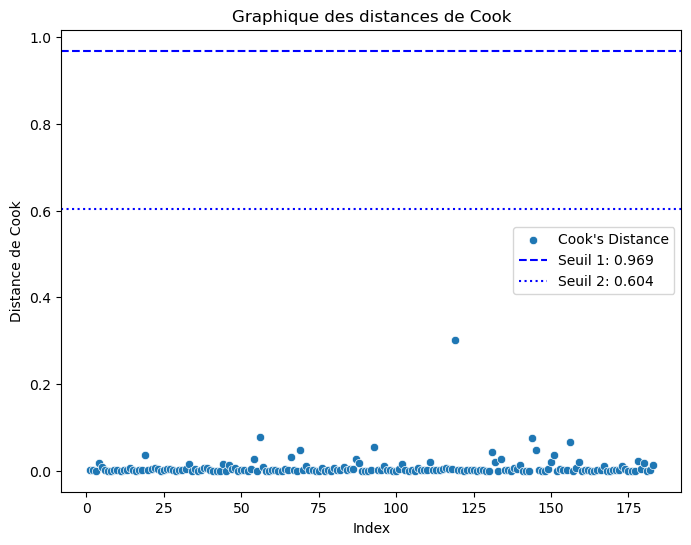

In [63]:
## distance de cook
from scipy.stats import f

# Number of observations
n = len(df["Country"])

# Get the model rank (number of estimated parameters)
p = mod2.df_model + 1  # Adding 1 for intercept

# Calculate Cook's distance
cook = mod2.get_influence().cooks_distance[0]

# Compute reference thresholds
s1 = f.ppf(0.5, p, n - p)
s2 = f.ppf(0.1, p, n - p)

# Create a DataFrame for Cook's distance
df_cook = pd.DataFrame({"cook": cook})

# Create the plot
plt.figure(figsize=(8, 6))

# 1. Scatter plot of Cook's distances
sns.scatterplot(x=np.arange(1, n+1), y=df_cook["cook"], label="Cook's Distance")

# 2. Add threshold lines
plt.axhline(y=s1, color="blue", linestyle="dashed", label=f"Seuil 1: {s1:.3f}")
plt.axhline(y=s2, color="blue", linestyle="dotted", label=f"Seuil 2: {s2:.3f}")

# 3. Add axis labels
plt.xlabel("Index")
plt.ylabel("Distance de Cook")
plt.title("Graphique des distances de Cook")

# Add legend
plt.legend()

# Show the plot
plt.show()

On remarque donc que aucun point n'est au dessus des deux seuils de la distance de cook, donc aucun point n'est suspect selon ce critère, ce qui signifie que aucun point n'est à la fois une valeur aberrante et un point levier.

#### III.E. Conclusion

Ainsi, il y a 8 observations aberrantes et 8 points leviers, mais aucun n'est à la fois l'un et l'autre. 
Pour les 8 observations aberrantes, on peut en déduire qu'elles ne proviennent pas du modèle, et pour les 8 points leviers, elles peuvent être quand même dans le modèle, mais ont beaucoup d'influence sur le modèle. 
Dans la mesure où il n'y a pas un trop grand nombre de points leviers et d'observations aberrantes, et dans la mesure où aucune des observations n'est à la fois un point levier et une observation aberrnate (ie aucune des observations ets inexpliquée par le modèle tout en modifiant beaucoup la régression), on décide de ne pas supprimer les observations atypiques. 
On en déduit que les résidus de notre modèle vérifient les hypothèses et sont plutot corrects, cela valide davantage la qualité de l'ajustement.

Dans cette partie on s'intéresse à la qualité des prédictions qu'on peut faire sur le modèle linéaire, qu'on évalue avec des intervalles de confiance

## IV. Sélection des variables

Après avoir analysé la significativité des variables du modèle, et les résidus, nous devons sélectionner les variables explicatives. Cela permettrait de simplifier le modèle (nous avons 19 variables explicatives, mais avons-nous besoin de toutes ces variables pour expliquer ou prédire l'espérance de vie d'un pays ?) Dans cette partie, nous étudions différentes manières de procéder à la sélection de variables : par les méthodes AIC / BIC, par l'usage du R2 ajusté, et par l'analyse du VIF. 

#### IV.A. Format du dataset

Dans cette partie, on se soucie d'avoir le dataframe sous une forme facilement exploitable pour la sélection des variables. Bien que le dataframe eût déjà été importé, nous l'importons de nouveau par un souci de simplicité : en effet, lors du travail sur le notebook, l'exécution de cellules en amont peut changer ce qu'il y a dans le dataframe, ce qui peut générer des confusions.

On précise qu'on normalise les données de façon à ce que leur comparaison soit plus facile et plus claire. 

In [71]:
df = pd.read_csv("Life Expectancy Data.csv")
df = df.drop('Status', axis=1)
df = df.drop('Year', axis=1)
df = df.groupby("Country", as_index=False).mean()
df = df.drop(columns = 'Country')
df = df.dropna(subset=['Life expectancy ']).reset_index(drop=True)
df = df.fillna(df.mean(numeric_only=True))

# 1. Séparer la colonne 'Country' si elle existe
country_col = df["Country"] if "Country" in df.columns else None

# 2. Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include='number').columns

# 3. Normalisation uniquement des colonnes numériques
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)

# 4. Reconstituer le DataFrame complet avec la colonne 'Country' si elle était là
if country_col is not None:
    df = pd.concat([country_col.reset_index(drop=True), df_scaled], axis=1)
else:
    df = df_scaled

df

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,-1.204107,1.086988,0.413583,-1.201290,-0.477603,-0.831618,-0.008141,-1.439609,0.416461,-2.132237,1.226513,-1.812956,-0.371486,-7.040978e-01,-8.199725e-02,2.887758,2.579489,-1.190609,-1.248518
1,0.647432,-1.248243,-0.256919,0.061829,-0.370418,1.141258,-0.294642,0.686536,-0.262691,0.985998,0.016888,0.963991,-0.371486,-5.263303e-01,-3.562099e-01,-0.795598,-0.766970,0.462986,0.045449
2,0.479607,-0.590156,-0.087267,-1.098793,-0.341352,-0.038780,-0.060056,0.665940,-0.118979,0.586425,-0.686602,0.588420,-0.371486,-4.536010e-01,2.632336e-01,0.306024,0.263637,0.378762,0.235011
3,-2.205603,1.707284,0.461128,0.294868,-0.432142,-0.497683,0.140647,-1.281178,0.576098,-2.273263,-1.045611,-2.093685,0.140017,-5.407722e-01,-7.682837e-02,0.330641,0.430885,-0.949167,-1.304150
4,0.636517,-0.388821,-0.262862,0.871946,0.176903,1.156992,-0.301265,0.012016,-0.268663,0.911567,-0.588372,0.979166,-0.365850,2.367531e-01,-1.101330e-16,-0.350949,-0.363165,-0.779316,-1.040412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.454364,-0.018728,-0.181818,0.733642,-0.501274,-0.732052,-0.280790,1.029935,-0.200190,-0.483020,-0.479656,-0.830402,-0.371486,1.816907e-16,-1.101330e-16,-0.787905,-0.800118,0.558088,0.259737
179,0.605817,-0.398594,-0.010546,-0.398391,-0.501274,0.524008,0.223987,-1.714090,-0.036175,0.786211,0.033515,0.580833,-0.361622,1.816907e-16,-1.101330e-16,2.480035,2.590036,-0.002000,-0.160597
180,-0.585335,0.490149,0.077521,-1.192679,-0.501274,-1.355260,0.041362,-0.300885,0.060165,-0.957023,-0.476160,-0.580022,-0.371486,1.816907e-16,-1.101330e-16,2.210784,2.138016,-0.853012,-1.151676
181,-1.672108,1.975731,0.026194,-0.619956,-0.440572,-0.521523,0.513217,-1.317221,0.064942,-1.129388,-0.046887,-0.481387,2.295937,-6.569721e-01,-1.917377e-01,0.499885,0.453486,-0.724219,-0.259498


#### IV.B. Calcul de R2, R2 ajusté, AIC, BIC

Les premières manières de sélectionner les variables sont suivant les critères AIC et BIC, qui pénalisent le modèle selon le nombre de variables (L'AIC pénalise le nombre de paramètres moins fortement que le BIC). On calcule les AIC et BIC sur le modèle, puis on choisit entre ces deux critères suivant celui qui donne le résultat minimum. On peut aussi utiliser le critère du R2 ajusté, mais le temps de calcul est beaucoup plus long. 

On calcule les AIC, BIC, R2 et R2 ajustés.

In [75]:
#/!\/!\ prend du temps (environ 5 minutes)

y = df['Life expectancy ']
X = df.drop(columns='Life expectancy ')

# 2. Paramètre : nombre max de variables
max_features = 19
results = []

# 3. Recherche exhaustive pour tous les sous-ensembles de variables jusqu’à 19
for k in range(1, max_features + 1):
    for subset in itertools.combinations(X.columns, k):
        X_subset = sm.add_constant(X[list(subset)])
        model = sm.OLS(y, X_subset).fit()
        results.append({
            'num_features': k,
            'variables': subset,
            'r2': model.rsquared,
            'adj_r2': model.rsquared_adj,
            'aic': model.aic,
            'bic': model.bic
        })

# 4. Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# 5. Pour chaque critère, sélectionner le meilleur modèle par taille
best_r2 = results_df.groupby('num_features')['r2'].max()
best_adj_r2 = results_df.groupby('num_features')['adj_r2'].max()
best_aic = results_df.groupby('num_features')['aic'].min()
best_bic = results_df.groupby('num_features')['bic'].min()

Le tableau comportant toutes les combinaisons de variables est appelé result_df.

In [77]:
results_df

,num_features,variables,r2,adj_r2,aic,bic
0,1,"(Adult Mortality,)",0.803607,0.802522,225.473744,231.892716
1,1,"(infant deaths,)",0.039966,0.034662,515.867643,522.286615
2,1,"(Alcohol,)",0.209897,0.205532,480.218192,486.637164
3,1,"(percentage expenditure,)",0.274911,0.270905,464.504155,470.923127
4,1,"(Hepatitis B,)",0.169635,0.165047,489.313736,495.732708
...,...,...,...,...,...,...
262138,17,"(Adult Mortality, infant deaths, Alcohol, Hepa...",0.932873,0.925957,61.018538,118.789289
262139,17,"(Adult Mortality, infant deaths, percentage ex...",0.931814,0.924789,63.881345,121.652096
262140,17,"(Adult Mortality, Alcohol, percentage expendit...",0.932229,0.925246,62.765846,120.536597
262141,17,"(infant deaths, Alcohol, percentage expenditur...",0.866442,0.852681,186.912893,244.683644


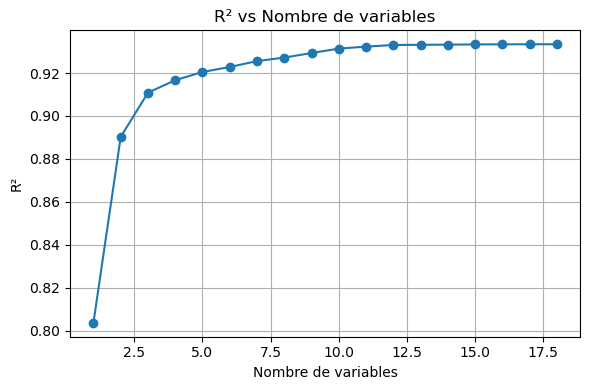

In [78]:
# R²
plt.figure(figsize=(6, 4))
plt.plot(best_r2.index, best_r2.values, marker='o')
plt.title('R² vs Nombre de variables')
plt.xlabel('Nombre de variables')
plt.ylabel('R²')
plt.grid(True)
plt.tight_layout()
plt.show()

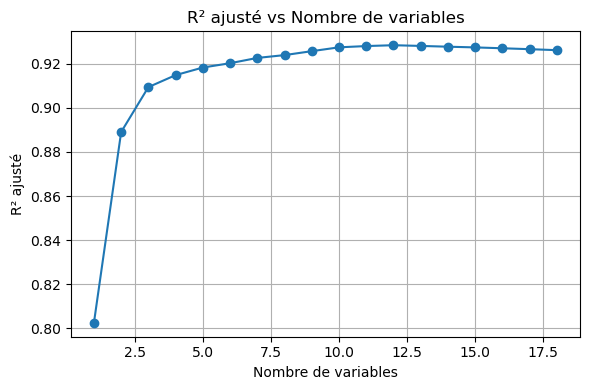

In [79]:
# R² ajusté
plt.figure(figsize=(6, 4))
plt.plot(best_adj_r2.index, best_adj_r2.values, marker='o')
plt.title('R² ajusté vs Nombre de variables')
plt.xlabel('Nombre de variables')
plt.ylabel('R² ajusté')
plt.grid(True)
plt.tight_layout()
plt.show()

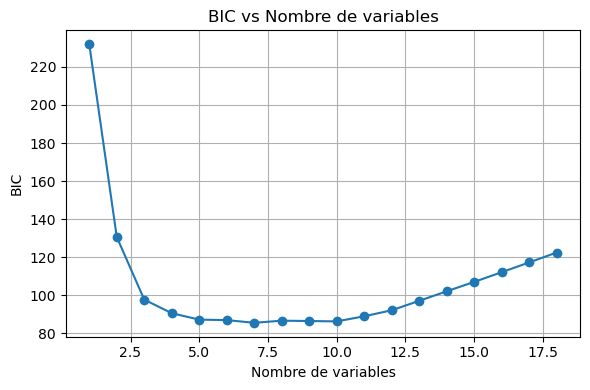

In [80]:
# BIC
plt.figure(figsize=(6, 4))
plt.plot(best_bic.index, best_bic.values, marker='o')
plt.title('BIC vs Nombre de variables')
plt.xlabel('Nombre de variables')
plt.ylabel('BIC')
plt.grid(True)
plt.tight_layout()
plt.show()

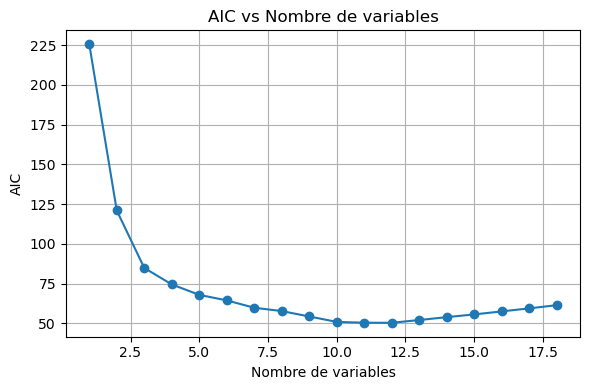

In [81]:
# AIC
plt.figure(figsize=(6, 4))
plt.plot(best_aic.index, best_aic.values, marker='o')
plt.title('AIC vs Nombre de variables')
plt.xlabel('Nombre de variables')
plt.ylabel('AIC')
plt.grid(True)
plt.tight_layout()
plt.show()

#### IV.C. Sélectionner les variables en fonction de AIC et BIC

Grâce aux calculs et aux plots précédents, nous pouvons maintenant sélectionner les variables les plus pertinentes pour nos modèles. 
En regardant le critère BIC, on voit que le minimum se trouve à 10 variables. Afin de trouver les 10 variables en question, on utilise le tableau results_df qui possède toutes les combinaisons de variables et on cherche quelle combinaison à le plus petit BIC.
On procède la même façon pour le critère AIC.

Concernant le R2, il n'est pas pris en compte car sa valeur augmente à mesure que le nombre de variables explicatives augmente, ce qui ne contribue pas à simplifier le modèle. Du côté du critère R2 ajusté, nous ne l'avons pas pris en compte car son coût de calcul est trop élevé.

Voici les résultats pour les variables explicatives sélectionnées avec respectivement les meilleurs BIC et AIC.

In [85]:
#combinaison de variables selon BIC
results_df[results_df["bic"]==best_bic[10]]["variables"].iloc[0]

('Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 ' BMI ',
 'under-five deaths ',
 'Diphtheria ',
 ' HIV/AIDS',
 'Income composition of resources',
 'Schooling')

In [86]:
#combinaison de variables selon AIC. 
results_df[results_df["aic"]==best_aic[12]]["variables"].iloc[0]

('Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 ' BMI ',
 'under-five deaths ',
 'Diphtheria ',
 ' HIV/AIDS',
 'Population',
 'Income composition of resources',
 'Schooling')

Ainsi, les résultats des critères AIC et BIC sont similaires. Le score minimal du AIC est inférieur au score minimal du BIC, le modèle donné par AIC semble donc meilleur que celui donné par BIC. Les variables qui semblent le mieux expliquer le modèle sont donc : 

* Adult Mortality
* infant deaths
* Alcohol
* percentage expenditure
* Hepatitis B
* BMI
* under-five deaths
* Diphtheria
* HIV/AIDS
* Population
* Income composition of resources
* Schooling


#### IV. D. Sélections des variables suivant le VIF

Une autre manière de sélectionner les variables pourrait être de supprimer les variables qui ont un VIF élevé.
Un VIF élevé est problématique, en effet, d'après le site https://www.datacamp.com/tutorial/variance-inflation-factor
"Multicollinearity causes standard errors to increase, which makes it harder to assess the significance of individual predictors. This happens because collinear variables carry similar information, making it difficult to separate their specific individual effects on the outcome variable. 

**Although multicollinearity doesn’t necessarily harm the model’s ability to predict, it does reduce the reliability and clarity of the coefficients**. This is especially problematic when we want to understand the individual impact of each predictor.

The variance inflation factor (VIF) serves as a precise diagnostic metric to identify multicollinearity. Unlike general observations about correlation, VIF isolates the combined effect of all predictors on each variable, highlighting interactions that might not be evident from pairwise correlations. "

Pour opérer la sélection basée sur le VIF, nous nous sommes appuyés sur le fait que selon plusieurs sources, un VIF supérieur à 10 indique une colonne à supprimer (comme ici : https://medium.com/@rasdhar.panchal/feature-selection-using-p-values-and-vif-in-linear-regression-6bf25b652d99). En partant des résultats obtenus dans l'analyse du VIF en section analyses descriptives, nous avons conclu que nous devions supprimer les variables : 
- infant death
- under five death
- thinness 5-9 years
- thinness 1-19 years
- polio
- diphteria

#### IV.E. Tests des différents modèles 

On souhaite maintenant tester les performances des différents modèles que nous avons sélectionné.
- Le premier modèle est le modèle de régression linéaire le plus simple, où toutes les variables du datafame sont considérées comme explicatives. 
- Le deuxième modèle contient les variables explicatives sélectionnées selon le meilleur BIC
- Le troisième modèle contient les variables explicatives sélectionnées selon le meilleur AIC
- Le dernier modèle contient des variables explicatives qui ont été sélectionnées à la main. En effet, après avoir constaté que certaines variables explicatives détaillées plus haut possédaient un VIF très élevé  et sont donc fortement corrélées entre elles, nous voulions regarder si les supprimer pourrait améliorer les performances du modèle. 

In [93]:
#Donc voici les différents modèles qu'on a avec les différentes variables sélectionnées 

#MODÈLE 1 : toutes les colonnes
modele_full =  ['Adult Mortality', 'infant deaths', 'Alcohol','percentage expenditure',
               'Hepatitis B', 'Measles ', ' BMI ','under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ',
               ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years',' thinness 5-9 years', 
               'Income composition of resources', 'Schooling']

#MODÈLE 2 : les meilleures colonnes selon le AIC
modele_aic = ['Adult Mortality','infant deaths','Alcohol','percentage expenditure','Hepatitis B',' BMI ','under-five deaths ','Diphtheria ',
 ' HIV/AIDS','Population','Income composition of resources','Schooling']

#MODÈLE 3 : les meilleures colonnes selon le BIC
modele_bic = ['Adult Mortality','infant deaths','Alcohol','percentage expenditure',' BMI ','under-five deaths ','Diphtheria ',
 ' HIV/AIDS','Income composition of resources','Schooling']

#MODÈLE 4 : Nous quand on enlève à la main les VIF élevés
#modele_vif = ['Adult Mortality', 'Alcohol','percentage expenditure', 'Hepatitis B', 
#              'Measles ', ' BMI ', 'Polio', 'Total expenditure', 'Diphtheria ',' HIV/AIDS', 'GDP', 'Population',
#              'Income composition of resources', 'Schooling']
modele_vif = ['Adult Mortality', 'Alcohol','percentage expenditure',
               'Hepatitis B', 'Measles ', ' BMI ', 'Total expenditure',
               ' HIV/AIDS', 'GDP', 'Population', 
               'Income composition of resources', 'Schooling']
              

Afin de tester les performances de nos modèles, on effectue une validation croisée. kfold créé ici 5 couples de jeux de données d'apprentissage et de test. Pour chaque couple apprentissage/entraînement, on calcule l'erreur moyenne absolue et l'erreur moyenne quadratique. Ensuite, on calcule la moyenne des erreurs obtenues afin d'avoir une erreur moyenne du modèle. 

In [95]:
#création de jeux de données d'apprentissage et d'entraînement
from sklearn.model_selection import KFold

# Suppose que tu as un DataFrame principal `df`
kf = KFold(n_splits=5, shuffle=True, random_state=42)
donnees = []

for train_idx, test_idx in kf.split(df):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)
    donnees.append((train_df, test_df))

In [96]:
#Fonction qui permet de faire une validation croisée et renvoie l'erreur moyenne quadratique et
#absolue en moyenne.

def validation_croisee(donnees,modele_a_tester):
    erreurs = []

    for i in range(len(donnees)):
        
        train_df = donnees[i][0]
        test_df = donnees[i][1]
    
        X_train = train_df[modele_a_tester]
        y_train = train_df['Life expectancy ']

        X_train = sm.add_constant(X_train)

        modele = sm.OLS(y_train, X_train).fit()

        X_test = test_df[modele_a_tester]
        X_test = sm.add_constant(X_test, has_constant='add')
        y_test = test_df['Life expectancy ']

        y_pred = modele.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        erreurs.append((mse, mae))
        
    somme_mae = 0
    somme_mse = 0
    
    for j in range (len(erreurs)):
        somme_mse += erreurs[i][0]
        somme_mae += erreurs[i][1]
        moy_mse = somme_mse/len(erreurs)
        moy_mae = somme_mae/len(erreurs)
        
    return (moy_mse,moy_mae)

La liste ci-dessous représente les erreurs obtenues sur les validations croisées pour respectivement le modèle avec toutes les variables, le modèle BIC, le modèle AIC et le modèle sans les variables à fort VIF.

In [98]:
#Cellule de code qui nous permet d'avoir toutes les erreurs de tous les modèles 

nos_modeles = [modele_full, modele_aic, modele_bic, modele_vif]
comp_erreurs = []

for i in range (len(nos_modeles)):
    tup_erreurs = validation_croisee(donnees,nos_modeles[i])
    comp_erreurs.append(tup_erreurs)
comp_erreurs

[(0.11707853070972377, 0.26563573073869085),
 (0.10793895158788833, 0.2538289480848782),
 (0.11347976803113795, 0.2623852582968629),
 (0.1494760853807238, 0.2909748078037811)]

On représente finalement visuellement les calculs qui ont été faits précedement.

🔍 Modèle Full :
  ➤ MSE : 0.1081
  ➤ MAE : 0.2468

🔍 Modèle AIC :
  ➤ MSE : 0.0981
  ➤ MAE : 0.2379

🔍 Modèle BIC :
  ➤ MSE : 0.1025
  ➤ MAE : 0.2423

🔍 Modèle VIF :
  ➤ MSE : 0.1101
  ➤ MAE : 0.2424



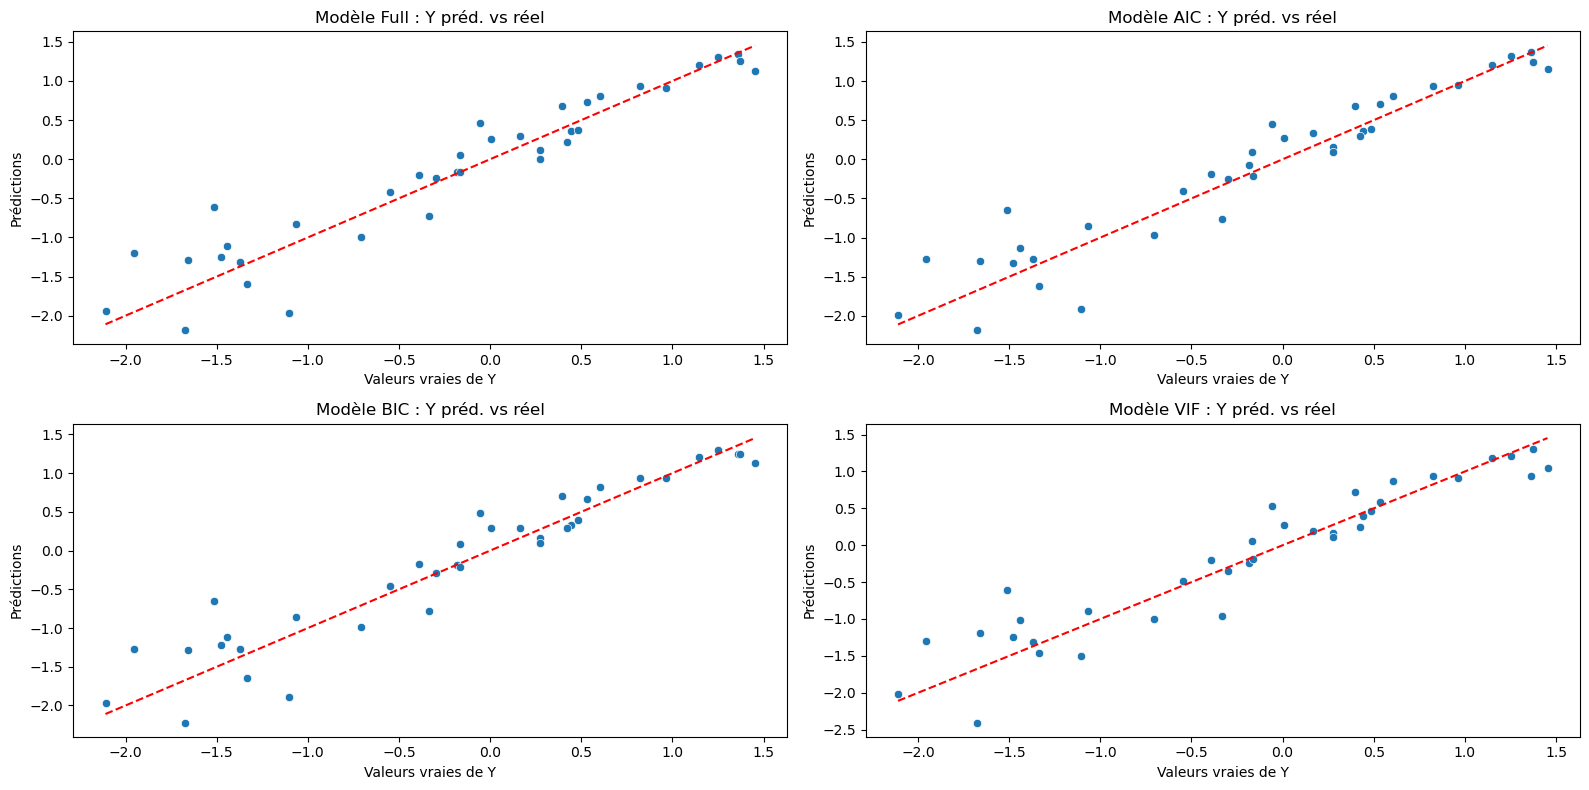

In [100]:
# Fold 1 : on extrait les données d'apprentissage et de test
train_df = donnees[0][0]
test_df = donnees[0][1]
y_true = test_df['Life expectancy ']

# Liste des modèles à tester et noms pour affichage
modeles = [modele_full, modele_aic, modele_bic, modele_vif]
noms_modeles = ["Modèle Full", "Modèle AIC", "Modèle BIC", "Modèle VIF"]

# Pour stocker les prédictions et les scores
predictions = []
scores = []

# Boucle sur les modèles
for i in range(len(modeles)):
    X_train = train_df[modeles[i]]
    y_train = train_df['Life expectancy ']
    X_train = sm.add_constant(X_train)

    modele = sm.OLS(y_train, X_train).fit()

    X_test = test_df[modeles[i]]
    X_test = sm.add_constant(X_test, has_constant='add')

    y_pred = modele.predict(X_test)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    predictions.append(y_pred)
    scores.append((mse, mae))

    print(f"🔍 {noms_modeles[i]} :")
    print(f"  ➤ MSE : {mse:.4f}")
    print(f"  ➤ MAE : {mae:.4f}\n")

# 📊 Visualisation : prédictions vs vraies valeurs
plt.figure(figsize=(16, 8))

for i in range(len(modeles)):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=y_true, y=predictions[i])
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Valeurs vraies de Y")
    plt.ylabel("Prédictions")
    plt.title(f"{noms_modeles[i]} : Y préd. vs réel")

plt.tight_layout()
plt.show()


Pour choisir entre le MSE et le MAE, on peut prendre en compte les valeurs observations isolées (valeurs aberrantes ou points leviers). Comme il y en a peu dans le dataset (environ 5%), le MAE peut être utilisé (la médiane minimise le MAE, et la moyenne minimise le MSE). Cependant, ce qui importe ici est de comparer les erreurs entre elles, le fait de comparer selon le MSE ou le MAE ne change pas grand chose dans les observations que l'on peut faire ici : en effet, on remarque que le meilleur modèle (au sens du modèle qui permet d'avoir le moins d'erreurs de prédiction) est celui donné par le critère AIC. Les modèles BIC, VIF et le modèle en entier donnent des résultats similaires. Dans tous les cas, avec AIC, nous avons réussi à baisser l'erreur moyenne légèrement., de 0.01 pt de pourcentage entre le modèle entier et le modèle AIC. Si cette différence parait minime, baisser le nombre de variables comporte un autre avantage : simplifier le modèle, ce qui le rend plus facile à calculer dans la réalité. 

#### IV.F. Conclusion - Choix du modèle 

Grâce aux tests que nous avons réalisés sur différents modèles, nous pouvons procéder à un choix sur celui qui nous semble être le plus pertinent : 
Le modèle AIC comporte la plus petite erreur quadratique moyenne (0,0981) et aussi la plus petite erreur absolue moyenne (0,2379).
Les variables sélectionnées par ce modèle sont donc 'Adult Mortality','infant deaths','Alcohol','percentage expenditure','Hepatitis B',' BMI ','under-five deaths ','Diphtheria ', HIV/AIDS','Population','Income composition of resources' et 'Schooling', ayant été jugées les meilleures pour prédire l'espérance de vie moyenne dans un pays.

On peut ensuite calculer les coefficients associés au meilleur modèle, et on obtient que les coefficients du meilleur modèle sont :  

In [105]:
X = df.drop(columns=[
    'Life expectancy ',
    'Measles ',
    'Polio',
    'Total expenditure',
    'GDP',
    ' thinness  1-19 years',
    ' thinness 5-9 years'
]
) 
#on supprime la variable qu'on veut expliquer of course mais aussi Country car non numérique
y = df['Life expectancy ']

print(X.dtypes[X.dtypes != 'float64']) 

X = sm.add_constant(X)

mod2 = sm.OLS(y, X).fit()

print(mod2.summary())

Series([], dtype: object)
                            OLS Regression Results                            
Dep. Variable:       Life expectancy    R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     197.6
Date:                Tue, 20 May 2025   Prob (F-statistic):           4.60e-93
Time:                        22:17:42   Log-Likelihood:                -12.217
No. Observations:                 183   AIC:                             50.43
Df Residuals:                     170   BIC:                             92.16
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

On peut alors expliciter le modèle initial comportant toutes les variables et le modèle final avec les variables explicatives que nous avons sélectionnées. 

Premier modèle : 
$$
\text{Life expectancy} =
- 0.6793 \cdot \text{under-five deaths}
+ 0.5560 \cdot \text{infant deaths}
- 0.5159 \cdot \text{Adult Mortality}
+ 0.1988 \cdot \text{Diphtheria}
+ 0.1154 \cdot \text{Income composition of resources}
+ 0.1072 \cdot \text{Schooling}
+ 0.0791 \cdot \text{BMI}
+ 0.0747 \cdot \text{Population}
+ 0.0717 \cdot \text{thinness 5-9 years}
+ 0.0675 \cdot \text{percentage expenditure}
+ 0.0571 \cdot \text{Alcohol}
- 0.0804 \cdot \text{HIV/AIDS}
- 0.0556 \cdot \text{thinness 1-19 years}
- 0.0492 \cdot \text{Hepatitis B}
+ 0.0124 \cdot \text{Total expenditure}
+ 0.0122 \cdot \text{Measles}
- 0.0155 \cdot \text{GDP}
- 0.0046 \cdot \text{Polio}
-7.216 \times 10^{-16}
$$


Modèle simplifié 
$$
\text{Life expectancy} =
- 0.6967 \cdot \text{under-five deaths}
+ 0.5923 \cdot \text{infant deaths}
- 0.5165 \cdot \text{Adult Mortality}
+ 0.1997 \cdot \text{Diphtheria}
+ 0.1144 \cdot \text{Schooling}
+ 0.1093 \cdot \text{Income composition of resources}
+ 0.0691 \cdot \text{BMI}
+ 0.0681 \cdot \text{Population}
- 0.0785 \cdot \text{HIV/AIDS}
+ 0.0590 \cdot \text{Alcohol}
+ 0.0513 \cdot \text{percentage expenditure}
- 0.0541 \cdot \text{Hepatitis B}
-7.216 \times 10^{-16}
$$


## Conclusion

À l’issue de notre analyse, nous avons pu construire un premier modèle de régression linéaire multiple déjà performant, respectant globalement l’ensemble des hypothèses statistiques requises. Les résidus se sont révélés faibles, sans valeur aberrante notable ni observation influente selon la distance de Cook, ce qui témoigne d’un bon ajustement du modèle aux données.

Bien que quelques variables explicatives possèdent un VIF élevé, elles sont toujours présentes dans le modèle final et cela n'a pas compromis la validité globale de l'analyse. L’utilisation des critères AIC et BIC s’est révélée efficace, permettant de réduire de près de moitié le nombre de variables explicatives, tout en baissant le taux d'erreur. Cela permet de simplifier le modèle.

Nous avons donc abouti à un modèle final qui est le suivant : 


$$
\text{Life expectancy} =
- 0.6967 \cdot \text{under-five deaths}
+ 0.5923 \cdot \text{infant deaths}
- 0.5165 \cdot \text{Adult Mortality}
+ 0.1997 \cdot \text{Diphtheria}
+ 0.1144 \cdot \text{Schooling}
+ 0.1093 \cdot \text{Income composition of resources}
+ 0.0691 \cdot \text{BMI}
+ 0.0681 \cdot \text{Population}
- 0.0785 \cdot \text{HIV/AIDS}
+ 0.0590 \cdot \text{Alcohol}
+ 0.0513 \cdot \text{percentage expenditure}
- 0.0541 \cdot \text{Hepatitis B}
-7.216 \times 10^{-16}
$$


Cela permet donc de mettre en évidence les facteurs déterminants de l'espérance de vie moyenne d'un pays. La mortalité des enfants de moins de 5 ans est un indicateur très explicatif de l'espérance de vie tout comme la mortalité globale infantile et la mortalité des adultes, ce qui semble cohérent. Cependant, cela n'aide pas nécessairement un pays à trouver des solutions pour augmenter l'espérance de vie.

En revanche, d'un point de vue sanitaire, augmenter la couverture immuntaire contre la Diphteria et augmenter le taux de scolarisation pourrait être un levier pour augmenter l'espérance de vie.